In [ ]:
!git clone https://github.com/abdksm/PROVEN-GNN.git

Cloning into 'PROVEN-GNN'...
remote: Enumerating objects: 534, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 534 (delta 18), reused 28 (delta 13), pack-reused 498 (from 1)
Receiving objects: 100% (534/534), 279.10 KiB | 12.13 MiB/s, done.
Resolving deltas: 100% (262/262), done.


In [ ]:
!gdown --id 1kUNwo7WjVpJ2D1GPsotiNO5FJnCqt--9 -O train_data.parquet
!gdown --id 1xhg62LTAJm5ityBKiXKv8Rsg0eSl9TJC -O test_data.parquet

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1kUNwo7WjVpJ2D1GPsotiNO5FJnCqt--9
From (redirected): https://drive.google.com/uc?id=1kUNwo7WjVpJ2D1GPsotiNO5FJnCqt--9&confirm=t&uuid=d66d314d-2712-452d-94b2-13f879722afb
To: /content/train_data.parquet
100% 589M/589M [00:06<00:00, 86.6MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1xhg62LTAJm5ityBKiXKv8Rsg0eSl9TJC
From (redirected): https://drive.google.com/uc?id=1xhg62LTAJm5ityBKiXKv8Rsg0eSl9TJC&confirm=t&uuid=ebddd008-18c9-4576-b2f1-1faed0237336
To: /content/test_dat

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.5 MB/s eta 0:00:00


In [ ]:
import time
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATv2Conv, global_mean_pool,SAGEConv
from torch_geometric.utils import to_networkx, degree
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, accuracy_score
import networkx as nx
import platform

In [ ]:
START_TIME = time.time()

In [ ]:
SEED = 25
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"OS: {platform.system()} {platform.release()}")
print(f"Processor: {platform.processor()}")

Using device: cuda
PyTorch version: 2.10.0+cu128
OS: Linux 6.6.113+
Processor: x86_64


In [ ]:
train_df = pd.read_parquet('/content/train_data.parquet')
train_df.head()

,id,node_feat,edge_index,edge_attr,label
0,12753,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, ...",0
1,6856,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 3, 3,...","[[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, ...",0
2,2311,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2,...","[[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, ...",1
3,278,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, ...",1
4,7937,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2,...","[[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, ...",0


In [ ]:
test_df = pd.read_parquet('/content/test_data.parquet')
test_df.head()

,id,node_feat,edge_index,edge_attr
0,9419,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, ..."
1,2905,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, ..."
2,7712,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,...","[[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, ..."
3,13344,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, ..."
4,18760,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, ..."


In [ ]:
test_ids = pd.read_csv('/content/PROVEN-GNN/data/public/test_ids.csv')
test_ids.head()

,id
0,9419
1,2905
2,7712
3,13344
4,18760


In [ ]:
print(f"Training graphs = {len(train_df)}")
print(f"Test graphs = {len(test_df)}")
print(f"Test Ids shape = {test_ids.shape}")

Training graphs = 2487
Test graphs = 622
Test Ids shape = (622, 1)


In [ ]:
label_col = 'target' if 'target' in train_df.columns else 'label'
class_counts = np.bincount(train_df[label_col])
print(f'Class Distribution -> non-vulnerable = {class_counts[0]} | vulnerable = {class_counts[1]}')

Class Distribution -> non-vulnerable = 1932 | vulnerable = 555


In [ ]:
f"Vulnerable ratio = {class_counts[1] / len(train_df['label'])}"

'Vulnerable ratio = 0.22316043425814233'

In [ ]:
for i,row in train_df.iterrows():
  print("shape = ",row['edge_attr'].shape)
  print(row)
  print(row['edge_index'])
  break

shape =  (1186,)
id                                                        12753
node_feat     [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
edge_index    [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
edge_attr     [[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, ...
label                                                         0
Name: 0, dtype: object
[array([  0,   0,   0, ..., 158, 158, 159])
 array([  1,   2,   3, ..., 159,   0, 158])]


In [ ]:
num_nodes = [len(row['node_feat']) for i,row in train_df.iterrows()]
num_edges = [len(row['edge_index'][0]) for i,row in train_df.iterrows()]
print(f"Average Nodes per graph = {np.mean(num_nodes)} +- {np.std(num_nodes)}")
print(f"Average Edgers per graph = {np.mean(num_edges)} +- {np.std(num_edges)}")

Average Nodes per graph = 83.70044229995979 +- 73.33825283106091
Average Edgers per graph = 551.280659429031 +- 547.8568883609432


In [ ]:
def build_graph(row, has_label=True):
    node_feat = row['node_feat']
    if isinstance(node_feat, np.ndarray) and node_feat.dtype == np.object_:
        node_feat = np.vstack(node_feat).astype(np.float32)
    else:
        node_feat = np.array(node_feat, dtype=np.float32)
    x = torch.tensor(node_feat, dtype=torch.float)

    edge_idx = row['edge_index']
    if isinstance(edge_idx, np.ndarray) and edge_idx.dtype == np.object_:
        edge_idx = np.stack(edge_idx).astype(np.int64)
    else:
        edge_idx = np.array(edge_idx, dtype=np.int64)
    edge_index = torch.tensor(edge_idx, dtype=torch.long)
    edge_attr_arr = row['edge_attr']
    if isinstance(edge_attr_arr, np.ndarray) and edge_attr_arr.dtype == np.object_:
        edge_attr_arr = np.vstack(edge_attr_arr).astype(np.float32)
    else:
        edge_attr_arr = np.array(edge_attr_arr, dtype=np.float32)
    edge_attr = torch.tensor(edge_attr_arr, dtype=torch.float)

    if has_label:
        y = torch.tensor(row[label_col], dtype=torch.long)
    else:
        y = None
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

In [ ]:
train_graphs = [build_graph(row,has_label=True) for i,row in train_df.iterrows()]
test_graphs = [build_graph(row,has_label=False) for i,row in test_df.iterrows()]

In [ ]:
print(f"Len of train graphs = {len(train_graphs)} & Len of test graphs = {len(test_graphs)}")

Len of train graphs = 2487 & Len of test graphs = 622


In [ ]:
sample = train_df.iloc[0]
sample_graph = build_graph(sample,has_label=True)

In [ ]:
G = to_networkx(sample_graph,to_undirected=True)

In [ ]:
deg = degree(sample_graph.edge_index[0],num_nodes=sample_graph.num_nodes)

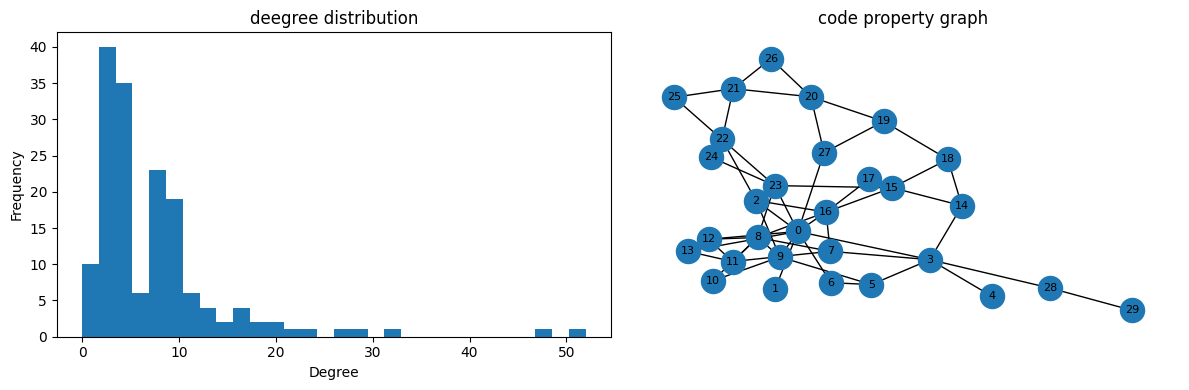

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(deg.numpy(), bins=30)
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.title('deegree distribution')
plt.subplot(1,2,2)
sub_n = list(G.nodes())[:30]
sub_G=G.subgraph(sub_n)
pos = nx.spring_layout(sub_G, seed=SEED)
nx.draw(sub_G, pos, with_labels=True, node_size=300, font_size=8)
plt.title('code property graph')
plt.tight_layout()
plt.show()

In [ ]:
y_labels = [g.y.item() for g in train_graphs]
spliter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(spliter.split(np.arange(len(train_graphs)), y_labels))
train_data = [train_graphs[i] for i in train_idx]
val_data   = [train_graphs[i] for i in val_idx]

In [ ]:
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=128, shuffle=False)
test_loader  = DataLoader(test_graphs, batch_size=128, shuffle=False)

# Models

In [ ]:
class GCN(nn.Module):
  def __init__(self,in_channels,hidden_channels,out_channels,num_layers,dropout):
    super().__init__()
    self.dropout = dropout
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    self.convs.append(GCNConv(in_channels,hidden_channels))
    self.bns.append(nn.BatchNorm1d(hidden_channels))
    for _ in  range(num_layers-1):
      self.convs.append(GCNConv(hidden_channels,hidden_channels))
      self.bns.append(nn.BatchNorm1d(hidden_channels))
    self.classifier = nn.Sequential(
        nn.Linear(hidden_channels,hidden_channels // 2),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_channels//2,out_channels)
    )
  def forward(self,data):
    x , edge_index,batch=  data.x, data.edge_index, data.batch
    for i, conv in enumerate(self.convs):
      x = conv(x, edge_index)
      x = self.bns[i](x)
      x = F.relu(x)
      x = F.dropout(x, p=self.dropout, training=self.training)
    x = global_mean_pool(x, batch)
    return self.classifier(x)


In [ ]:
class GraphSAGE(nn.Module):
  def __init__(self, in_channels,hidden_channels, out_channels, num_layers, dropout):
    super().__init__()
    self.dropout = dropout
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    self.convs.append(SAGEConv(in_channels, hidden_channels))
    self.bns.append(nn.BatchNorm1d(hidden_channels))
    for _ in range(num_layers - 1):
      self.convs.append(SAGEConv(hidden_channels,hidden_channels))
      self.bns.append(nn.BatchNorm1d(hidden_channels))
    self.classifier = nn.Sequential(
        nn.Linear(hidden_channels,hidden_channels // 2),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_channels//2,out_channels)
    )
  def forward(self,data):
    x , edge_index,batch=  data.x, data.edge_index, data.batch
    for i, conv in enumerate(self.convs):
      x = conv(x, edge_index)
      x = self.bns[i](x)
      x = F.relu(x)
      x = F.dropout(x, p=self.dropout, training=self.training)
    x = global_mean_pool(x, batch)
    return self.classifier(x)

In [ ]:
class GAT(nn.Module):
  def __init__(self,in_channels, hidden_channels, out_channels, num_layers, no_heads, dropout):
    super().__init__()
    self.dropout = dropout
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    self.convs.append(GATv2Conv(in_channels,hidden_channels,heads=no_heads,concat=True, dropout=dropout))
    self.bns.append(nn.BatchNorm1d(hidden_channels * no_heads))
    for i in range(num_layers-2):
      self.convs.append(GATv2Conv(hidden_channels * no_heads,hidden_channels,heads=no_heads,concat=True, dropout=dropout))
      self.bns.append(nn.BatchNorm1d(hidden_channels * no_heads))
    self.convs.append(GATv2Conv(hidden_channels * no_heads, hidden_channels, heads=1, concat=False))
    self.classifier = nn.Sequential(
        nn.Linear(hidden_channels, hidden_channels // 2),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_channels//2,out_channels)
    )
  def forward(self,data):
    x,edge_index,edge_attr,batch=  data.x, data.edge_index, data.edge_attr, data.batch
    for i,conv in enumerate(self.convs):
      x = conv(x,edge_index)
      if i < len(self.bns) - 1:
        x = self.bns[i](x)
      x = F.elu(x)
      x = F.dropout(x,p=self.dropout, training=self.training)
    x = global_mean_pool(x,batch)
    return self.classifier(x)

In [ ]:
def train(model,loader, optimizer, criterion):
  model.train()
  tot_loss = 0
  for data in loader:
    data = data.to(device)
    optimizer.zero_grad()
    out=model(data)
    loss=criterion(out,data.y)
    loss.backward()
    optimizer.step()
    tot_loss += loss.item() * data.num_graphs
  return tot_loss / len(loader.dataset)
@torch.no_grad()
def eval(model,loader,criterion):
  model.eval()
  t_loss=0
  all_preds,all_labels=[],[]
  for data in loader:
    data=data.to(device)
    out=model(data)
    loss=criterion(out,data.y)
    t_loss += loss.item() * data.num_graphs
    pred = out.argmax(dim=1).cpu().numpy()
    all_preds.extend(pred)
    all_labels.extend(data.y.cpu().numpy())
  f1=f1_score(all_labels,all_preds,average='macro')
  acc=accuracy_score(all_labels,all_preds)
  return t_loss/len(loader.dataset),f1,acc

In [ ]:
def training(model,train_loader, val_loader, epochs,lr,weight_decay,patience):
  model = model.to(device)
  optimizer = torch.optim.Adam(model.parameters(),lr=lr, weight_decay=weight_decay)
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
  criterion = nn.CrossEntropyLoss()
  best_val_f1 = 0.0
  best_state =None
  patience_ctr = 0
  history  ={'train_loss':[],'val_loss':[],"val_f1":[],'val_acc':[]}
  start_time=  time.time()
  for epoch in range(1,epochs+1):
    train_loss = train(model,train_loader,optimizer,criterion)
    val_loss,val_f1,val_acc = eval(model,val_loader,criterion)
    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_acc'].append(val_acc)
    if val_f1 > best_val_f1:
      best_val_f1 = val_f1
      best_state = copy.deepcopy(model.state_dict())
      patience_ctr=0
    else:
      patience_ctr+=1
      if patience_ctr >= patience:
        print(f"early stopping @ epoch {epoch}")
        break
    if epoch % 10 == 0:
      print(f"Epoch = {epoch} | Train Loss: {train_loss:.3f} | Val Loss= {val_loss:.3f} | Val F1 = {val_f1:.3f}")

  tot_time = time.time() - start_time
  model.load_state_dict(best_state)
  return model,best_val_f1,history,tot_time

In [ ]:
def plotter(hist):
  plt.figure(figsize=(15,5))
  plt.subplot(1,3,1)
  plt.plot(hist['train_loss'],label="Train Loss")
  plt.plot(hist['val_loss'],label='Val Loss')
  plt.title('Loss')
  plt.xlabel("Epoch")
  plt.legend()

  plt.subplot(1,3,2)
  plt.plot(hist['val_acc'],label="Val Acc")
  plt.title("accuracy")
  plt.xlabel("Epoch")
  plt.legend()

  plt.subplot(1,3,3)
  plt.plot(hist['val_f1'],label = "Validation F1")
  plt.title('f1 score')
  plt.xlabel('epoch')
  plt.legend()
  plt.show()

In [98]:
in_channels = train_graphs[0].x.shape[1]
out_channels= 2
hps= []
run_id = 0

In [99]:
print("GCN")
model_gcn = GCN(in_channels=in_channels,hidden_channels = 64,out_channels=out_channels,num_layers=2,dropout=0.5)
best_model_gcn,val_f1_gcn, hist_gcn, t_gcn = training(model_gcn,train_loader, val_loader, epochs=300,lr=0.001,weight_decay=1e-3,patience=40)
hps.append({'run': run_id+1, 'arch': 'GCN', 'hidden': 64, 'layers': 2, 'val_f1': val_f1_gcn, 'time_sec': t_gcn})
run_id += 1

GCN
Epoch = 10 | Train Loss: 0.166 | Val Loss= 0.365 | Val F1 = 0.785
Epoch = 20 | Train Loss: 0.045 | Val Loss= 1.085 | Val F1 = 0.603
Epoch = 30 | Train Loss: 0.011 | Val Loss= 0.503 | Val F1 = 0.805
Epoch = 40 | Train Loss: 0.008 | Val Loss= 0.512 | Val F1 = 0.834
Epoch = 50 | Train Loss: 0.006 | Val Loss= 0.525 | Val F1 = 0.849
Epoch = 60 | Train Loss: 0.006 | Val Loss= 0.528 | Val F1 = 0.840
Epoch = 70 | Train Loss: 0.006 | Val Loss= 0.537 | Val F1 = 0.839
Epoch = 80 | Train Loss: 0.005 | Val Loss= 0.539 | Val F1 = 0.838
early stopping @ epoch 90


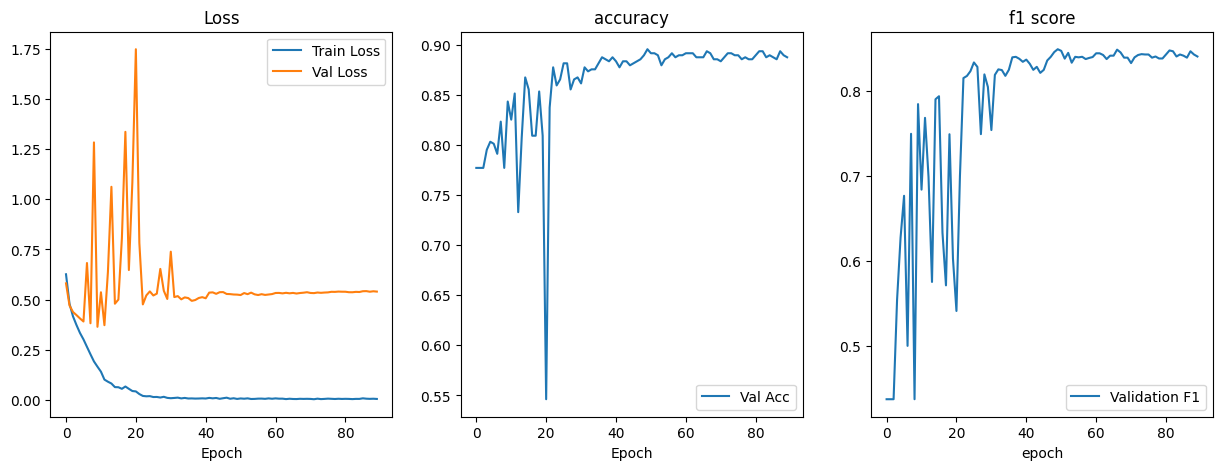

In [100]:
plotter(hist_gcn)

In [101]:
print("GraphSAGE")
model_sage = GraphSAGE(in_channels=in_channels,hidden_channels = 64,out_channels=out_channels,num_layers=2,dropout=0.5)
best_model_sage,val_f1_sage, hist_sage, t_sage = training(model_sage,train_loader, val_loader,epochs=300,lr=0.01,weight_decay=5e-4,patience=40)
hps.append({'run': run_id+1, 'arch': 'GraphSAGE', 'hidden': 64, 'layers': 2, 'val_f1': val_f1_sage, 'time_sec': t_sage})
run_id += 1

GraphSAGE
Epoch = 10 | Train Loss: 0.178 | Val Loss= 0.492 | Val F1 = 0.703
Epoch = 20 | Train Loss: 0.076 | Val Loss= 0.596 | Val F1 = 0.761
Epoch = 30 | Train Loss: 0.023 | Val Loss= 0.583 | Val F1 = 0.801
Epoch = 40 | Train Loss: 0.026 | Val Loss= 0.625 | Val F1 = 0.818
Epoch = 50 | Train Loss: 0.013 | Val Loss= 0.696 | Val F1 = 0.806
Epoch = 60 | Train Loss: 0.015 | Val Loss= 0.679 | Val F1 = 0.807
Epoch = 70 | Train Loss: 0.014 | Val Loss= 0.692 | Val F1 = 0.813
early stopping @ epoch 78


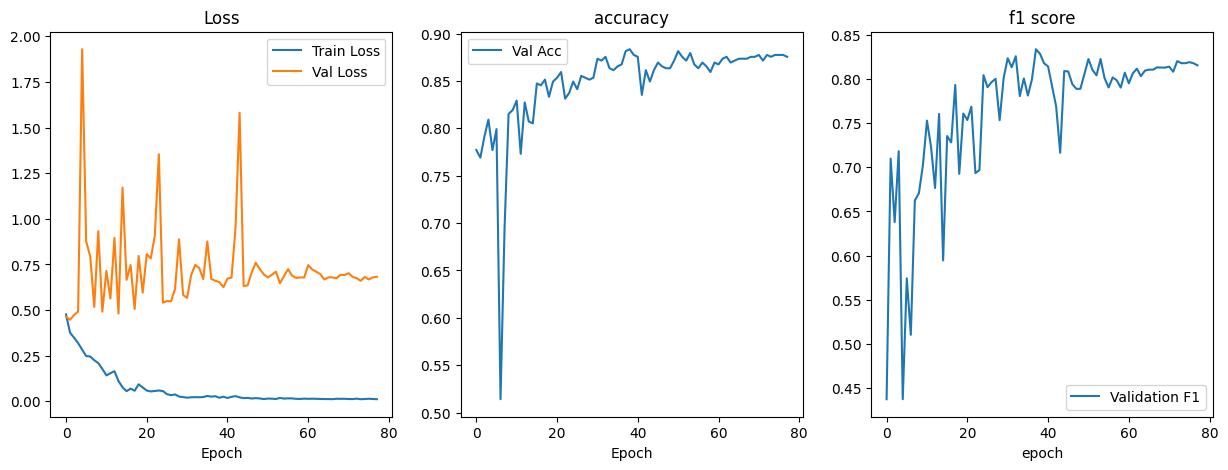

In [102]:
plotter(hist_sage)

In [103]:
print("GAT")
model_gat = GAT(in_channels=in_channels,hidden_channels = 64,out_channels=out_channels,num_layers=3,no_heads=4,dropout=0.6)
best_model_gat, best_f1_gat, hist_gat, t_gat = training(model_gat,train_loader, val_loader, epochs=500, lr=0.001, weight_decay=5e-3, patience=40)
hps.append({'run': run_id+1, 'arch': 'GAT', 'hidden': 64, 'heads': 4, 'layers': 2, 'val_f1': best_f1_gat, 'time_sec': t_gat})
run_id += 1

GAT
Epoch = 10 | Train Loss: 0.319 | Val Loss= 0.417 | Val F1 = 0.716
Epoch = 20 | Train Loss: 0.259 | Val Loss= 0.415 | Val F1 = 0.728
Epoch = 30 | Train Loss: 0.204 | Val Loss= 0.400 | Val F1 = 0.704
Epoch = 40 | Train Loss: 0.167 | Val Loss= 0.867 | Val F1 = 0.507
Epoch = 50 | Train Loss: 0.114 | Val Loss= 0.581 | Val F1 = 0.595
Epoch = 60 | Train Loss: 0.083 | Val Loss= 0.396 | Val F1 = 0.769
Epoch = 70 | Train Loss: 0.077 | Val Loss= 0.430 | Val F1 = 0.767
Epoch = 80 | Train Loss: 0.064 | Val Loss= 0.426 | Val F1 = 0.775
Epoch = 90 | Train Loss: 0.054 | Val Loss= 0.440 | Val F1 = 0.773
Epoch = 100 | Train Loss: 0.052 | Val Loss= 0.449 | Val F1 = 0.772
Epoch = 110 | Train Loss: 0.045 | Val Loss= 0.449 | Val F1 = 0.774
early stopping @ epoch 119


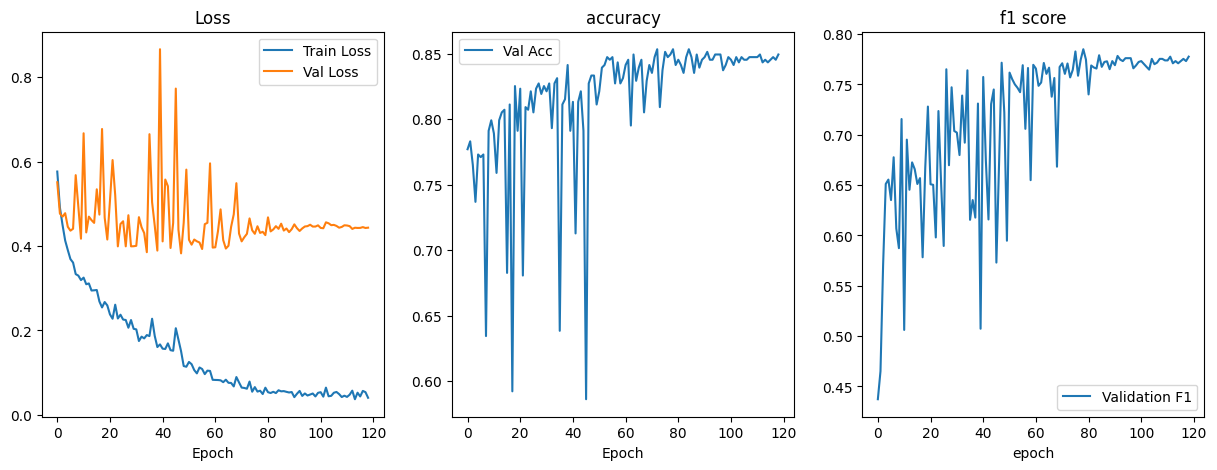

In [104]:
plotter(hist_gat)

In [105]:
print("GCN v2")
model_gcn_v2 = GCN(in_channels=in_channels,hidden_channels = 128,out_channels=out_channels,num_layers=3,dropout=0.5)
best_model_gcn_v2,val_f1_gcn_v2, hist_gcn_v2, t_gcn_v2 = training(model_gcn_v2,train_loader, val_loader, epochs=300,lr=0.001,weight_decay=1e-3,patience=40)
hps.append({'run': run_id+1, 'arch': 'GCN v2', 'hidden': 128, 'layers': 3, 'val_f1': val_f1_gcn, 'time_sec': t_gcn})
run_id += 1

GCN v2
Epoch = 10 | Train Loss: 0.079 | Val Loss= 0.535 | Val F1 = 0.740
Epoch = 20 | Train Loss: 0.018 | Val Loss= 0.946 | Val F1 = 0.710
Epoch = 30 | Train Loss: 0.010 | Val Loss= 0.569 | Val F1 = 0.820
Epoch = 40 | Train Loss: 0.004 | Val Loss= 0.682 | Val F1 = 0.789
Epoch = 50 | Train Loss: 0.003 | Val Loss= 0.670 | Val F1 = 0.796
Epoch = 60 | Train Loss: 0.002 | Val Loss= 0.633 | Val F1 = 0.805
early stopping @ epoch 70


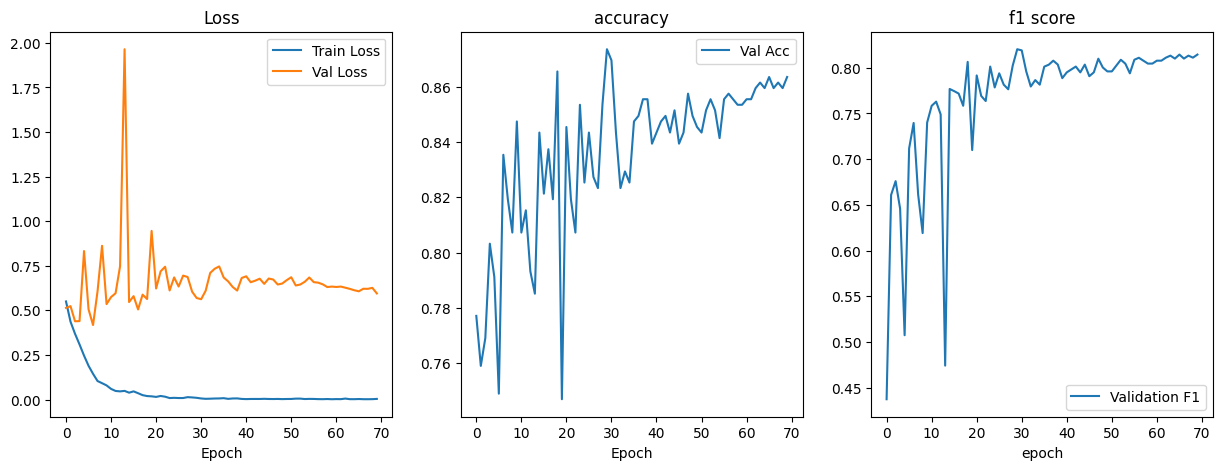

In [106]:
plotter(hist_gcn_v2)

In [107]:
print("GraphSAGE v2")
model_sage_v2 = GraphSAGE(in_channels=in_channels,hidden_channels = 128,out_channels=out_channels,num_layers=2,dropout=0.5)
best_model_sage_v2,val_f1_sage_v2, hist_sage_v2, t_sage_v2 = training(model_sage_v2,train_loader, val_loader,epochs=300,lr=0.01,weight_decay=5e-4,patience=40)
hps.append({'run': run_id+1, 'arch': 'GraphSAGE v2', 'hidden': 128, 'layers': 2, 'val_f1': val_f1_sage, 'time_sec': t_sage})
run_id += 1

GraphSAGE v2
Epoch = 10 | Train Loss: 0.147 | Val Loss= 1.341 | Val F1 = 0.544
Epoch = 20 | Train Loss: 0.081 | Val Loss= 1.116 | Val F1 = 0.618
Epoch = 30 | Train Loss: 0.046 | Val Loss= 0.909 | Val F1 = 0.733
Epoch = 40 | Train Loss: 0.009 | Val Loss= 0.508 | Val F1 = 0.842
Epoch = 50 | Train Loss: 0.011 | Val Loss= 0.579 | Val F1 = 0.840
Epoch = 60 | Train Loss: 0.007 | Val Loss= 0.585 | Val F1 = 0.837
Epoch = 70 | Train Loss: 0.006 | Val Loss= 0.522 | Val F1 = 0.856
Epoch = 80 | Train Loss: 0.005 | Val Loss= 0.543 | Val F1 = 0.848
Epoch = 90 | Train Loss: 0.005 | Val Loss= 0.538 | Val F1 = 0.853
Epoch = 100 | Train Loss: 0.006 | Val Loss= 0.544 | Val F1 = 0.852
Epoch = 110 | Train Loss: 0.005 | Val Loss= 0.540 | Val F1 = 0.847
early stopping @ epoch 112


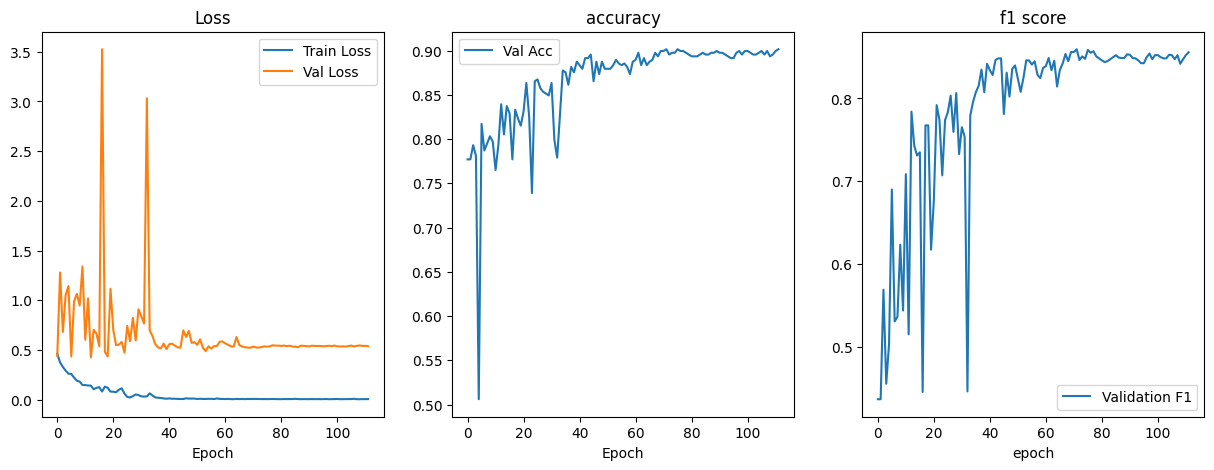

In [108]:
plotter(hist_sage_v2)

In [109]:
pd.DataFrame(hps)

,run,arch,hidden,layers,val_f1,time_sec,heads
0,1,GCN,64,2,0.849291,44.550048,NaN
1,2,GraphSAGE,64,2,0.833732,38.387204,NaN
2,3,GAT,64,2,0.784942,135.888072,4.0
3,4,GCN v2,128,3,0.849291,44.550048,NaN
4,5,GraphSAGE v2,128,2,0.833732,38.387204,NaN


# SubmissioN

In [111]:
best_model_gcn.eval()
test_preds = []
with torch.no_grad():
  for data in test_loader:
    data = data.to(device)
    out = best_model_gcn(data)
    pred = out.argmax(dim=1).cpu().numpy()
    test_preds.extend(pred)

In [112]:
submission = pd.DataFrame({
    'id': test_ids['id'].values,
    'y_pred': test_preds
})

In [113]:
submission.head()

,id,y_pred
0,9419,0
1,2905,1
2,7712,1
3,13344,0
4,18760,0


In [114]:
submission.to_csv('predictions.csv', index=False)

In [116]:
torch.save(best_model_gcn.state_dict(),'best_model_gcn.pt')

In [115]:
TOTAL_TIME = time.time() - START_TIME
TOTAL_TIME

4092.8721575737